In [1]:
import debugpy; debugpy.listen(("0.0.0.0", 5678))

('0.0.0.0', 5678)

In [1]:
import sys
sys.path.append("CPE883-2025-02/modules/models/")
sys.path.append("CPE883-2025-02/dataloaders/3W/")
sys.path.append("/3W")
path = "CPE883-2025-02/experiments/3W/timecaps/"

In [17]:
from scipy.signal import spectrogram
import torch


### Teste do Espectograma

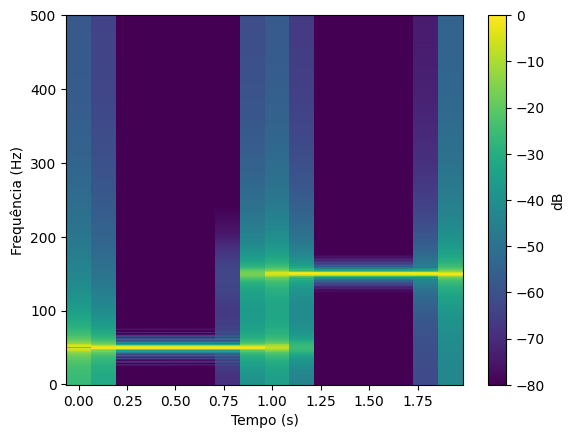

In [3]:
fs = 1000.0
Tsec = 2.0
t = torch.arange(int(fs*Tsec)) / fs
# Sinal muda de 50 Hz para 150 Hz após 1 s
x = torch.sin(2*torch.pi*50*t) * (t < 1.0) + torch.sin(2*torch.pi*150*t) * (t >= 1.0)

params = TorchSpecParams(
    fs=fs,
    n_fft=1024,
    win_length=512,
    hop_length=128,
    window="hann",
    scaling="spectrum",
    pre_emphasis=0.0,
    to_db=True,
    ref_power="max",
    top_db=80.0,
)

out = compute_spectrogram_torch(x, params, device=torch.device("cuda" if torch.cuda.is_available() else "cpu"))
# Ex.: out["db"].shape == (1,1,F,T)
# Para visualizar (opcional):
import matplotlib.pyplot as plt
plt.pcolormesh(out["t"].cpu(), out["f"].cpu(), out["db"][0,0].cpu(), shading="auto")
plt.xlabel("Tempo (s)"); plt.ylabel("Frequência (Hz)"); plt.colorbar(label="dB"); plt.show()

### Teste do Espectograma no DataLoader

In [8]:
import importlib
importlib.reload(sys.modules['loader'])
from loader import Loader3W

In [9]:
ld = Loader3W()
#ld.get_ids_from_wells_with_event_type([8])
#ld.extract_stats(['ABER-CKP', 'P-ANULAR', 'P-PDG','P-TPT','T-MON-CKP','T-PDG','T-TPT'])
#ld.save_stats(path+'stats.pkl')
ld.load_stats(path+'stats.pkl')

In [10]:
s=ld.preprocess()
s = s.send(None)  # Get first item from generator

In [ ]:
out, f_cpd, t_dt, params = make_temp_spec(s['T-TPT'], win="2D", hop="1H")

# Escolha o que plotar: dB ou potência (PSD)
Z = out["db"][0, 0].cpu().numpy() if "db" in out else out["power"][0, 0].cpu().numpy()

plt.figure(figsize=(10, 4.5))
plt.pcolormesh(t_dt, f_cpd, Z, shading="auto")
plt.ylabel("Frequência (ciclos/dia)")
plt.xlabel("Tempo")
plt.title("Espectrograma da temperatura")
if "db" in out:
    plt.colorbar(label="Nível (dB re 1.0)")
else:
    plt.colorbar(label="PSD (unidade²/Hz)")
# formatação agradável do eixo de data
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gcf().autofmt_xdate()
plt.tight_layout()

AttributeError: 'DatetimeIndex' object has no attribute 'DateFormatter'